# Семинар 10, часть 1 - Нейросетевое обнаружение объектов

**Содержит ДЗ**

***

![oops](https://habrastorage.org/r/w1560/getpro/habr/upload_files/d6d/992/21e/d6d99221ef7388b1f5f6ae3e47944d37.png)

_Источник: https://habr.com/ru/companies/slsoft/articles/869766/_



## Цели семинара

1. **Понимать и интерпретировать ключевые метрики качества**  
   - Определять IoU и объяснять, как он отражает точность расположения рамок.  
   - Объяснять, как считается mAP и что показывает средняя точность детектора.

2. **Сравнивать два основных подхода к детекции**  
   - Описывать архитектурные и функциональные отличия двухэтапных (two-stage) и одноэтапных (one-stage) детекторов.  
   - Обосновывать выбор подхода в зависимости от требований к точности и скорости.

3. **Разбирать механизм работы двухэтапных детекторов**  
   - Объяснять алгоритм Selective Search для генерации Region Proposals.  
   - Описывать ключевые компоненты R-CNN: извлечение признаков CNN, SVM-классификация и регрессия рамок.

4. **Понимать принципы одноэтапных детекторов на примере YOLO**  
   - Объяснять, как YOLO формулирует задачу детекции как регрессию end-to-end.  
   - Назвать основные улучшения в эволюции версий YOLO (v1 → v4/5/…).

5. **Анализировать компромиссы «скорость vs точность»**  
   - Оценивать, в каких сценариях критичнее реальное время работы, а в каких — максимальная точность.  
   - Приводить примеры приложений для каждого подхода (автономное вождение, видеонаблюдение, аналитика).


## Вводные вопросы

(_это не дз_)

1. **Что такое bounding box в задаче детекции объектов?**

2. **Как вычисляется метрика IoU (Intersection over Union)?**

3. **В чём разница между Precision и Recall при оценке детектора?**

4. **Чем двухэтапный детектор (two-stage) принципиально отличается от одноэтапного (one-stage)?**


## Импорт библиотек, настройка окружения

In [6]:
# понадобится в разделе Object detection
!pip install selectivesearch

# https://github.com/sizhky/torch_snippets
# используется в "Modern Computer Vision with PyTorch"
!pip install -U torch_snippets

!pip install fastcore==1.7.29 fastai==2.7.19

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 KB 870.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.8/234.8 KB 2.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.2/29.2 MB 12.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 15.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.9/156.9 KB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 KB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.3/124.3 KB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 14.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 KB 12.2 MB/s eta

In [1]:
import os
import glob
from pathlib import Path

# from google.colab import files

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

import selectivesearch
from skimage.segmentation import felzenszwalb

# import albumentations as A
# import albumentations.pytorch

import torch
from torch import nn

import torchvision
from torchvision import transforms, models, datasets

from torch_snippets import *
from torch_snippets.torch_loader import Report

/home/panzer/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Метрики качества детекции

Источник: [материалы курса "Основы глубинного обучения" ВШЭ](https://github.com/hse-ds/iad-deep-learning)

### Intersection over union (IoU)

<img src=https://www.pyimagesearch.com/wp-content/uploads/2016/09/iou_equation.png width="400">


Пример как это выглядит в коде

```
def intersection_over_union(dt_bbox: np.array, gt_bbox: np.array) -> float:
    """
    Intersection over Union between two bboxes
    (x0, y0) - coordinates of the upper left bbox corner
    (x1, y1) - coordinates of the down right bbox corner

    :param dt_bbox: list or numpy array of size (4,) [x0, y0, x1, y1]
    :param gt_bbox: list or numpy array of size (4,) [x0, y0, x1, y1]
    :return : intersection over union
    """
    # upper left corner
    int_x0 = max(dt_bbox[0], gt_bbox[0])
    int_y0 = max(dt_bbox[1], gt_bbox[1])
    # bottom right corner
    int_x1 = min(dt_bbox[2], gt_bbox[2])
    int_y1 = min(dt_bbox[3], gt_bbox[3])

    intersection = max(int_x1 - int_x0, 0) * max(int_y1 - int_y0, 0)
    dt_area = (dt_bbox[2] - dt_bbox[0]) * (dt_bbox[3] - dt_bbox[1])
    gt_area = (gt_bbox[2] - gt_bbox[0]) * (gt_bbox[3] - gt_bbox[1])

    return intersection / (dt_area + gt_area - intersection)
```

### mAP - Mean Average Precision

#### Precision и Recall

Сперва вспомним базовые понятия точности и полноты.

$$ Precision = {TP \over TP + FP} $$

$$ Recall = {TP \over TP + FN} $$

- TP - True Positive
- FP - False Positive
- FN - False Negative
<br> <br>

__Precision__ - доля объектов, названных классификатором положительными и при этом действительно являющимися положительными, среди всех объектов, названных классификатором положительными.

__Recall__ - доля объектов, названных классификатором положительными и при этом действительно являющимися положительными, среди всех истинно положительных объектов.

В задаче детекции метки TP, FP, FN (чаще всего) выдаются по следующей логике:

- метка TP выдается в случае, если IoU > 0.5 и класс определен правильно
- метка FP выдается в случае, если IoU <= 0.5 и/или если Bounding Box'ы дублируются
- метка FN выдается, если IoU > 0.5, но неправильно определен класс и/или если бокса нет совсем
<br> <br>

#### Наглядные примеры

* зеленый цвет - истинный бокс и класс
* синий - наши предсказания

**True Positive**

У нас два волка, оба определены своим классом и боксы, очевидно, имеют IoU больше 0.5.

<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2021/seminars/sem06/TruePositiveVolks.jpg" width="400">

**False Positive**

Несмотря на то, что класс определен правильно и бокс, в целом, выглядит логично на своем месте, IoU слишком мал, поэтому такая детекция получает метку FP.

<img src="https://github.com/hse-ds/iad-deep-learning/blob/master/2021/seminars/sem06/FalsePositiveVolk.jpg?raw=1" width="400">

**False Negative**

Потому что, несмотря на хорошее пересечение предсказанного бокса с целевым, класс с высокой уверенностью определен неправильно.

<img src="https://github.com/hse-ds/iad-deep-learning/blob/master/2021/seminars/sem06/FalseNegativeVolk.jpg?raw=1" width="400">

#### PR-кривая

Далее, для подсчёта mAP нужно построить PR-кривую. Напомним, что это кривая, у которой по оси Y - значение Precision, а по оси X - значение recall. Эти значения считаются при переборе пороговых вероятностей, начиная с которых объект помечается положительным классом.

Для задачи бинарной классификации мы когда-то строили такую кривую, теперь рассмотрим чуть более сложный случай, где у нас три класса: Волк, Лев и Тигр; плюс решается задача детекции, а не классификации.

Внизу представлена таблица с игрушечными данными по предсказаниям модели. Допустим, из 7 объектов в датасете у нас только 3 волка. В данном случае мы называли объект "действительно волком", если он имел правильный класс и IoU не менее 0.5. Получается, имеем задачу вида one vs all, где интересующим нас классом будет являться именно "волк".

|Номер строки| Уверенность в том что волк (истинный класс)    |IoU не менее 0.5?   |  Precision  |  Recall |
|------------|------------------------|----------------------|-------------|---------|
|1           |0.92 (Волк)     |   True    |    1.0     |    0.33 |
|2           |0.83 (Волк)     |   True    |    1.0     |    0.67 |
|3           |0.77 (Волк)     |   False   |    0.67    |    0.67 |
|4           |0.71 (Лев)      |   False   |    0.50    |    ...  |
|5           |0.67 (Тигр)     |   False   |    0.40    |    .... |
|6           |0.54 (Волк)     |   True    |    0.50    |    .... |
|7           |0.47 (Тигр)     |   False   |    0.50    |    1.0  |

**Посчитаем Precision и Recall для порога в 0.9:**

Здесь все легко: взяли порог в 0.9 и называем волками всех, у кого уверенность в классе "Волк" больше 0.9. Один TP, отсутсвуют FP и два FN (2 и 6 строчки).

$$Precision ={  1 \over 1 + 0} = 1.0$$

$$Recall = {1 \over 1 + 2} = 0.33$$

**для порога в 0.8:**

Здесь тоже без дополнительных сложностей: таким порогом во второй строчке у нас нашелся еще один TP, соответственно убавился один FN. Остальное осталось так же.

$$Precision ={  2 \over 2 + 0} = 1.0$$

$$Recall = {2 \over 2 + 1} = 0.67$$

**для порога в 0.75:**

А вот при пороге в 0.75 в третьей строчке замечаем, что, несмотря на то что истинный класс действительно "Волк" (чем мы и называем данный объект), IoU c истинным боксом меньше 0.5, поэтому присваиваем метку FP.

$$Precision ={  2 \over 2 + 1} = 0.67$$

$$Recall = {2 \over 2 + 1} = 0.67$$

#### Задание 1

Посчитать недостающие в таблице значения precision и recall и сравнить с изображенной PR кривой.

PR кривая будет выглядеть следующим образом:

<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2021/seminars/sem06/pr_uno.png">

#### Монотонная PR-кривая

**Average Precision (AP)** стандартно **определяется как AUC-PR**, то есть как площадь по PR кривой. Из-за того что Precision и Recall находятся в отрезке от 0 до 1, AP также определена на этом отрезке. Чем ближе к 1, тем качественнее модель.

Для удобства вычислений и чуть большей устойчивости к перестановке, вместо того чтобы терпеть возникшую немонотонность, для всех совпадающих значений recall'a берется максимальный справа от текущей точки precision, то есть график изменится следующим образом:

<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2021/seminars/sem06/pr_dos.png">

Технология та же: для вычисления AP считается AUC под красной кривой:

$$AP = 1 * 0.67 + (1 - 0.67) * 0.5 = 0.835.$$

#### Подсчёт mAP

Все предыдущие графики, наша первая табличка и значения AP считались для одного класса "Волк". Понятно, что подобные значения можно посчитать для каждого класса в выборке. И каждый раз будет принцип one vs all, где различаются нужный класс и "все остальные".

Метрика __mean Average Precison__ считается как среднее между __AP__ каждого класса, т.е.:

$$mAP = \sum_{c \in C} AP(c),$$
где С — множество классов.

## Семейства моделей детекции

<img src="https://drive.google.com/uc?export=view&id=13dspvoIGqXbhR_22qeko9VBXAZyJNEw3" alt="detection_families.jpeg" width="500"/>

**Коротко про каждый подход:**

1. **RCNN подход**: Предполагает **двухэтапный** проход модели по изображению, где изначально выделяются зоны способами классического компьютерного зрения, а затем происходит уже знакомая нам классификация объектов в зонах и предсказание с помощью задачи регрессии координат box для объектов.

2. **YOLO подход**: **Одноэтапный** детектор удаляет процесс извлечения области интереса и напрямую классифицирует и регрессирует анкерные блоки-кандидаты. YOLO — это архитектура обнаружения объектов, которая называется YOU ONLY LOOK ONCE. Это включает в себя использование одной нейронной сети, обученной от начала до конца, для обработки фотографии и прогнозирования ограничивающих рамок и меток классов для каждой ограничивающей рамки напрямую. Существует несколько версий, которые постоянно совершенствуются, например: YOLOv3, YOLOv4, YOLOv5, [YOLOv7](https://paperswithcode.com/paper/yolov7-trainable-bag-of-freebies-sets-new).

<img src="https://drive.google.com/uc?export=view&id=1S0io2XVglh1gD4u394pgyiBr0RiiAozj" alt="detection_families2.jpeg" width="800"/>

## Two-stage: Архитектура RCNN

> Girshick, Ross, et al. "Rich feature hierarchies for accurate object detection and semantic segmentation." *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2014.
https://arxiv.org/abs/1311.2524

- Источник материалов: [Modern Computer Vision with PyTorch](https://github.com/PacktPublishing/Modern-Computer-Vision-with-PyTorch)

### Selective Search

Первым этапом двухстадийных детекторов является извлечение Region Proposals.
В RCNN для этого используется алгоритм Selective Search.

1. **Быстрая начальная сегментация**  
   - Изображение разбивают на мелкие «суперпиксели» (обычно алгоритм Felzenszwalb & Huttenlocher).  
   - Каждому сегменту приписывают простые признаки: цветовую гистограмму, текстурные фильтры, площадь, положение.

2. **Определяем «сходство» соседних сегментов**  
   - Считают четыре меры схожести:  
     1. _Color similarity_ — перекрытие цветовых гистограмм.  
     2. _Texture similarity_ — перекрытие текстурных гистограмм (Sobel, LBP).  
     3. _Size similarity_ — малые регионы сливаются охотнее, чтобы сократить число областей.  
     4. _Fill similarity_ — насколько плотно два региона заполняют общий минимум-огибающий прямоугольник.

3. **Иерархическое агломеративное объединение**  
   - Пока есть пары с наибольшим сходством, сливаем их в более крупный сегмент, пересчитываем признаки и обновляем таблицу сходств.  
   - На каждом шаге новый сегмент порождает **bounding box**-кандидат.

4. **Мульти-скейл + разнообразие стратегий**  
   - Алгоритм запускают с разными настройками начальной сегментации (разные _k_-параметры, цветовые пространства).  
   - Полученные наборы боксов объединяют и удаляют дубликаты (NMS).

**Итог:** ~2000 прямоугольников, покрывающих ≈ 97–98 % реальных объектов при IoU ≥ 0.5.  
Selective Search не требует обучения, но медленный (секунды на кадр) и генерирует много лишних предложений — именно поэтому позже его заменили на Region Proposal Network в Faster R-CNN.








#### Алгоритм Felzenszwalb & Huttenlocher (кратко)

1. **Изображение → граф**  
   - Пиксели — вершины, соседние пиксели соединены рёбрами.
   - Вес ребра = разница цветов между пикселями.

2. **Сортировка рёбер**  
   - Все рёбра сортируют по возрастанию весов (сначала похожие пиксели).

3. **Объединение сегментов**  
   - Идут по отсортированным рёбрам и объединяют компоненты, если различие между ними меньше некоторого порога.
   - Порог зависит от внутренней неоднородности сегментов и размера компоненты.

4. **Очистка мелких сегментов**  
   - Очень маленькие сегменты объединяют с соседями.

**Итог:** быстрое получение качественных сегментов («суперпикселей»). Подходит как первая стадия многих алгоритмов компьютерного зрения (например, Selective Search).


In [2]:
from skimage import data

img = data.astronaut()

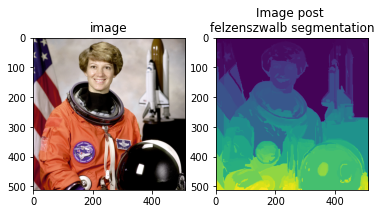

In [3]:
segments_fz = felzenszwalb(img, scale=200)
segments_fz.shape
f, ax = plt.subplots(1, 2, figsize=(6, 6))
ax[0].imshow(img)
ax[0].set_title("image")
ax[1].imshow(segments_fz)
ax[1].set_title("Image post \nfelzenszwalb segmentation");

In [4]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates

In [5]:
candidates = extract_candidates(img)

/home/panzer/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


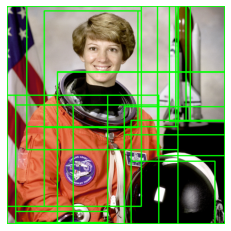

In [6]:
def show_bboxes(img, bboxes):
    img = img.copy()
    for bb in bboxes:
        x, y, w, h = bb
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_bboxes(img, candidates)

### Датасет

Загрузим датасет OpenImages Bus Trucks - https://www.kaggle.com/datasets/sixhky/open-images-bus-trucks

Этот датасет является подмножеством датасета Google Open Images v6, включающим только автобусы и грузовики.

Для загрузки датасета нам понадобится аккаунт Kaggle и API токен.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sixhky/open-images-bus-trucks")

print("Path to dataset files:", path)

Path to dataset files: /home/panzer/.cache/kagglehub/datasets/sixhky/open-images-bus-trucks/versions/1


In [13]:
IMAGE_ROOT = path+'/images/images'
DF_RAW = pd.read_csv(path+'/df.csv')
print(DF_RAW.head())

            ImageID  Source LabelName  Confidence      XMin      XMax  \
0  0000599864fd15b3  xclick       Bus           1  0.343750  0.908750   
1  00006bdb1eb5cd74  xclick     Truck           1  0.276667  0.697500   
2  00006bdb1eb5cd74  xclick     Truck           1  0.702500  0.999167   
3  00010bf498b64bab  xclick       Bus           1  0.156250  0.371250   
4  00013f14dd4e168f  xclick       Bus           1  0.287500  0.999375   

       YMin      YMax  IsOccluded  IsTruncated  ...  IsDepiction  IsInside  \
0  0.156162  0.650047           1            0  ...            0         0   
1  0.141604  0.437343           1            0  ...            0         0   
2  0.204261  0.409774           1            1  ...            0         0   
3  0.269188  0.705228           0            0  ...            0         0   
4  0.194184  0.999062           0            1  ...            0         0   

   XClick1X  XClick2X  XClick3X  XClick4X  XClick1Y  XClick2Y  XClick3Y  \
0  0.421875  0.34

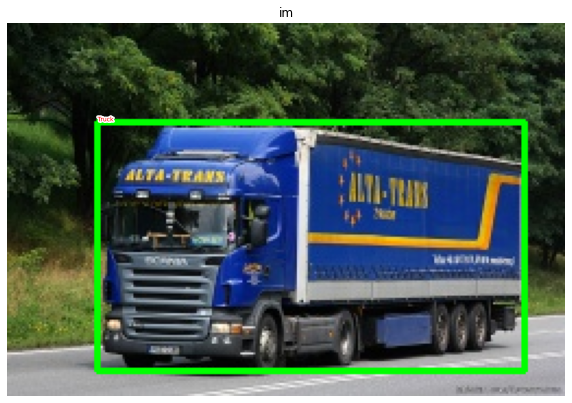

In [14]:
class OpenImages(torch.utils.data.Dataset):
    def __init__(self, df, image_folder=IMAGE_ROOT):
        self.root = image_folder
        self.df = df
        self.unique_images = df['ImageID'].unique()
    def __len__(self): return len(self.unique_images)
    def __getitem__(self, ix):
        image_id = self.unique_images[ix]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)[...,::-1] # conver BGR to RGB
        h, w, _ = image.shape
        df = self.df.copy()
        df = df[df['ImageID'] == image_id]
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist()
        classes = df['LabelName'].values.tolist()
        return image, boxes, classes, image_path
ds = OpenImages(df=DF_RAW)
im, bbs, clss, _ = ds[9]
show(im, bbs=bbs, texts=clss, sz=10)  # torch_snippets

In [15]:
def extract_iou(boxA, boxB, epsilon=1e-5):
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    width = (x2 - x1)
    height = (y2 - y1)
    if (width<0) or (height <0):
        return 0.0
    area_overlap = width * height
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    area_combined = area_a + area_b - area_overlap
    iou = area_overlap / (area_combined+epsilon)
    return iou

In [16]:
FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
N = 500
for ix, (im, bbs, labels, fpath) in enumerate(ds):
    if(ix==N):
        break
    H, W, _ = im.shape
    candidates = extract_candidates(im)
    candidates = np.array([(x,y,x+w,y+h) for x,y,w,h in candidates])
    ious, rois, clss, deltas = [], [], [], []
    ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T
    for jx, candidate in enumerate(candidates):
        cx,cy,cX,cY = candidate
        candidate_ious = ious[jx]
        best_iou_at = np.argmax(candidate_ious)
        best_iou = candidate_ious[best_iou_at]
        best_bb = _x,_y,_X,_Y = bbs[best_iou_at]
        if best_iou > 0.3: clss.append(labels[best_iou_at])
        else : clss.append('background')
        delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W,H,W,H])
        deltas.append(delta)
        rois.append(candidate / np.array([W,H,W,H]))
    FPATHS.append(fpath)
    IOUS.append(ious)
    ROIS.append(rois)
    CLSS.append(clss)
    DELTAS.append(deltas)
    GTBBS.append(bbs)
FPATHS = [f'{IMAGE_ROOT}/{stem(f)}.jpg' for f in FPATHS]
FPATHS, GTBBS, CLSS, DELTAS, ROIS = [item for item in [FPATHS, GTBBS, CLSS, DELTAS, ROIS]]

/home/panzer/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/home/panzer/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/home/panzer/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.w

In [17]:
targets = pd.DataFrame(flatten(CLSS), columns=['label'])
label2target = {l:t for t,l in enumerate(targets['label'].unique())}
target2label = {t:l for l,t in label2target.items()}
background_class = label2target['background']

In [18]:
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
def preprocess_image(img):
    img = torch.tensor(img).permute(2,0,1)
    img = normalize(img)
    return img.to(device).float()
def decode(_y):
    _, preds = _y.max(-1)
    return preds

In [19]:
class RCNNDataset(torch.utils.data.Dataset):
    def __init__(self, fpaths, rois, labels, deltas, gtbbs):
        self.fpaths = fpaths
        self.gtbbs = gtbbs
        self.rois = rois
        self.labels = labels
        self.deltas = deltas
    def __len__(self): return len(self.fpaths)
    def __getitem__(self, ix):
        fpath = str(self.fpaths[ix])
        image = cv2.imread(fpath, 1)[...,::-1]
        H, W, _ = image.shape
        sh = np.array([W,H,W,H])
        gtbbs = self.gtbbs[ix]
        rois = self.rois[ix]
        bbs = (np.array(rois)*sh).astype(np.uint16)
        labels = self.labels[ix]
        deltas = self.deltas[ix]
        crops = [image[y:Y,x:X] for (x,y,X,Y) in bbs]
        return image, crops, bbs, labels, deltas, gtbbs, fpath
    def collate_fn(self, batch):
        input, rois, rixs, labels, deltas = [], [], [], [], []
        for ix in range(len(batch)):
            image, crops, image_bbs, image_labels, image_deltas, image_gt_bbs, image_fpath = batch[ix]
            crops = [cv2.resize(crop, (224,224)) for crop in crops]
            crops = [preprocess_image(crop/255.)[None] for crop in crops]
            input.extend(crops)
            labels.extend([label2target[c] for c in image_labels])
            deltas.extend(image_deltas)
        input = torch.cat(input).to(device)
        labels = torch.Tensor(labels).long().to(device)
        deltas = torch.Tensor(deltas).float().to(device)
        return input, labels, deltas

In [20]:
n_train = 9*len(FPATHS)//10
train_ds = RCNNDataset(FPATHS[:n_train], ROIS[:n_train], CLSS[:n_train], DELTAS[:n_train], GTBBS[:n_train])
test_ds = RCNNDataset(FPATHS[n_train:], ROIS[n_train:], CLSS[n_train:], DELTAS[n_train:], GTBBS[n_train:])

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=2,
                                           collate_fn=train_ds.collate_fn,
                                           drop_last=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=2,
                                          collate_fn=test_ds.collate_fn,
                                          drop_last=True)

### Модель

In [21]:
vgg_backbone = models.vgg16(pretrained=True)
vgg_backbone.classifier = nn.Sequential()
for param in vgg_backbone.parameters():
    param.requires_grad = False

/home/panzer/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/panzer/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/panzer/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:33<00:00, 16.4MB/s] 


In [22]:
class RCNN(nn.Module):
    def __init__(self):
        super().__init__()
        feature_dim = 25088
        self.backbone = vgg_backbone
        self.cls_score = nn.Linear(feature_dim, len(label2target))
        self.bbox = nn.Sequential(
              nn.Linear(feature_dim, 512),
              nn.ReLU(),
              nn.Linear(512, 4),
              nn.Tanh(),
            )
        self.cel = nn.CrossEntropyLoss()
        self.sl1 = nn.L1Loss()
    def forward(self, input):
        feat = self.backbone(input)
        cls_score = self.cls_score(feat)
        bbox = self.bbox(feat)
        return cls_score, bbox
    def calc_loss(self, probs, _deltas, labels, deltas):
        detection_loss = self.cel(probs, labels)
        ixs, = torch.where(labels != 0)
        _deltas = _deltas[ixs]
        deltas = deltas[ixs]
        self.lmb = 10.0
        if len(ixs) > 0:
            regression_loss = self.sl1(_deltas, deltas)
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss.detach()
        else:
            regression_loss = 0
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss

### Обучение

In [23]:
def train_batch(inputs, model, optimizer, criterion):
    input, clss, deltas = inputs
    model.train()
    optimizer.zero_grad()
    _clss, _deltas = model(input)
    loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
    accs = clss == decode(_clss)
    loss.backward()
    optimizer.step()
    return loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()

@torch.no_grad()
def validate_batch(inputs, model, criterion):
    input, clss, deltas = inputs
    with torch.no_grad():
        model.eval()
        _clss,_deltas = model(input)
        loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
        _, _clss = _clss.max(-1)
        accs = clss == _clss
    return _clss, _deltas, loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()

Training on: cuda


/tmp/ipykernel_167216/241273796.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  deltas = torch.Tensor(deltas).float().to(device)


EPOCH: 1.000  val_loss: 1.827  val_loc_loss: 0.629  val_regr_loss: 0.120  val_acc: 0.766  (937.39s - 0.00s remaining)))))

100%|██████████| 102/102 [00:00<00:00, 17713.61it/s]


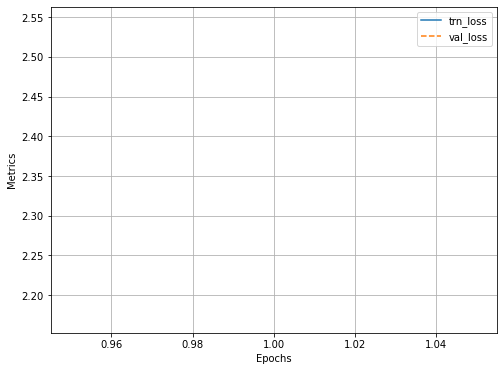

In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

model = RCNN().to(device)
criterion = model.calc_loss
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
n_epochs = 1
log = Report(n_epochs)  # torch_snippets

for epoch in range(n_epochs):

    _n = len(train_loader)
    for ix, inputs in enumerate(train_loader):
        loss, loc_loss, regr_loss, accs = train_batch(inputs, model,
                                                      optimizer, criterion)
        pos = (epoch + (ix+1)/_n)
        log.record(pos, trn_loss=loss.item(), trn_loc_loss=loc_loss,
                   trn_regr_loss=regr_loss,
                   trn_acc=accs.mean(), end='\r')

    _n = len(test_loader)
    for ix,inputs in enumerate(test_loader):
        _clss, _deltas, loss, \
        loc_loss, regr_loss, accs = validate_batch(inputs,
                                                model, criterion)
        pos = (epoch + (ix+1)/_n)
        log.record(pos, val_loss=loss.item(), val_loc_loss=loc_loss,
                val_regr_loss=regr_loss,
                val_acc=accs.mean(), end='\r')

# Plotting training and validation metrics
log.plot_epochs('trn_loss,val_loss'.split(','))

### Тестирование

In [25]:
def test_predictions(filename, show_output=True):
    img = np.array(cv2.imread(filename, 1)[...,::-1])
    candidates = extract_candidates(img)
    candidates = [(x,y,x+w,y+h) for x,y,w,h in candidates]
    input = []
    for candidate in candidates:
        x,y,X,Y = candidate
        crop = cv2.resize(img[y:Y,x:X], (224,224))
        input.append(preprocess_image(crop/255.)[None])
    input = torch.cat(input).to(device)
    with torch.no_grad():
        model.eval()
        probs, deltas = model(input)
        probs = torch.nn.functional.softmax(probs, -1)
        confs, clss = torch.max(probs, -1)
    candidates = np.array(candidates)
    confs, clss, probs, deltas = [tensor.detach().cpu().numpy() for tensor in [confs, clss, probs, deltas]]

    ixs = clss!=background_class
    confs, clss, probs, deltas, candidates = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates]]
    bbs = (candidates + deltas).astype(np.uint16)
    ixs = torchvision.ops.nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
    confs, clss, probs, deltas, candidates, bbs = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
    if len(ixs) == 1:
        confs, clss, probs, deltas, candidates, bbs = [tensor[None] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
    if len(confs) == 0 and not show_output:
        return (0,0,224,224), 'background', 0
    if len(confs) > 0:
        best_pred = np.argmax(confs)
        best_conf = np.max(confs)
        best_bb = bbs[best_pred]
        x,y,X,Y = best_bb
    _, ax = plt.subplots(1, 2, figsize=(20,10))
    show(img, ax=ax[0])
    ax[0].grid(False)
    ax[0].set_title('Original image')
    if len(confs) == 0:
        ax[1].imshow(img)
        ax[1].set_title('No objects')
        plt.show()
        return
    ax[1].set_title(target2label[clss[best_pred]])
    show(img, bbs=bbs.tolist(), texts=[target2label[c] for c in clss.tolist()], ax=ax[1], title='predicted bounding box and class')
    plt.show()
    return (x,y,X,Y),target2label[clss[best_pred]],best_conf

/home/panzer/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


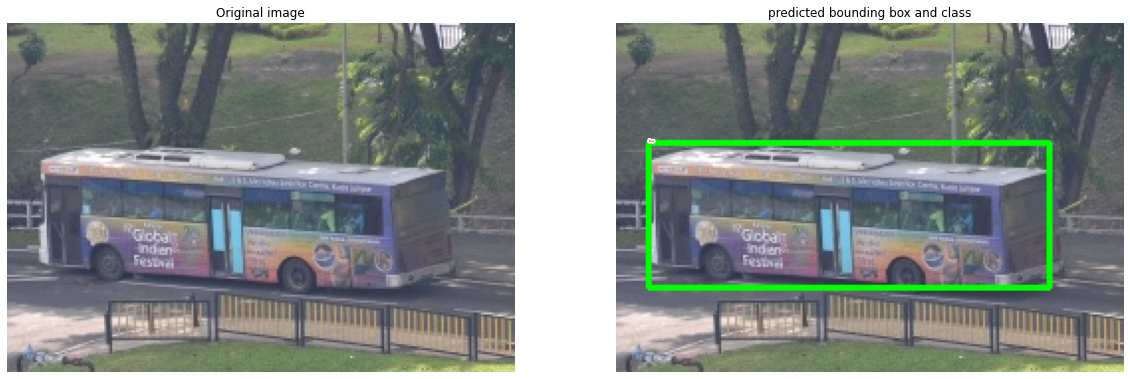

((16, 60, 218, 133), 'Bus', 0.9619648)

In [26]:
image, crops, bbs, labels, deltas, gtbbs, fpath = test_ds[7]
test_predictions(fpath)

## Region Proposal Network

1. **Общая сверточная база**  
   - Использует те же глубокие свёрточные слои, что и основная детектирующая сеть (например, в Faster R-CNN).

2. **Sliding window + Anchor boxes**  
   - По выходу свёрточного слоя движется «окно» фиксированного размера.
   - В каждой точке генерируется набор «якорей» (anchors) разных масштабов и соотношений сторон.

3. **Два «головных» слоя**  
   - **Классификатор объект-фон**: для каждого анкера предсказывает вероятность, что в нём есть объект.  
   - **Регрессор координат**: для анкер-прямоугольников выдаёт смещения (dx, dy, dw, dh) для уточнения границ.

4. **Отбор и фильтрация**  
   - Отбираются анкеры с высокой «objectness» score.  
   - Применяется Non-Maximum Suppression (NMS) для удаления сильно перекрывающихся предложений.

5. **End-to-end обучение**  
   - RPN обучается одновременно с детектором: общие свёрточные веса оптимизируются под обе задачи.
   - Благодаря этому RPN быстро генерирует качественные Region Proposals «на лету», без внешних алгоритмов (Selective Search).

**Итог:** RPN заменяет медленный классический генератор предложений, обеспечивая высокую скорость и эффективность в двухэтапных детекторах.  


#### Вопрос 1

_(оценивается)_

**Как работает Non-Maximum Suppression (NMS) и почему он важен?**

Ответ:

Non-Maximum Suppression (NMS) — это алгоритм, который из множества перекрывающихся прямоугольников с оценками уверенности оставляет только наиболее вероятные, удаляя дубликаты (у которыйх ниже confidence). Он важен для получения точных и чистых результатов при детекции объектов, убирая лишние пересечения и ложные срабатывания.


## One-stage: You Only Look Once


https://arxiv.org/abs/1506.02640

> Redmon, Joseph, et al. "You only look once: Unified, real-time object detection." Proceedings of the IEEE conference on computer vision and pattern recognition. 2016.

**One-stage детекторы — основная идея:**

- Единый проход сети: детекция формулируется как прямая регрессия от пикселей изображения к координатам рамок + классам. Никакого отдельного поиска "кандидатов" (region proposals) — вся работа выполняется одной CNN.

- Плотный вывод: сеть сканирует изображение свёрточными слоями; на каждой позиции её выхода (обычно это ячейка сетки) одновременно предсказывает несколько ограничивающих рамок (anchor / bounding box) и вероятности классов.

- Скорость > точность: отказ от второго этапа резко ускоряет инференс (десятки FPS), зато рамки локализуются чуть грубее. Современные улучшения свели этот разрыв почти к нулю.


### Самостоятельная работа

_(вопросы и упражнения далее будут оцениваться)_

#### Вопрос 2

**В YOLOv1 изображение 448 × 448 делят на сетку 7 × 7. Сколько чисел предсказывает сеть для каждой ячейки при B = 2 боксах и C = 20 классах, и что это за числа?**

Ответ:
# ![YOLOv1 Output Structure](./image.png)

7*7*(B*5+C) = 7*7*(2*5+20) = 49*30 = 1470 чисел на выходе. 

тензор размерности 7x7x30, 7 на 7 - грид, 30 - это С классов и B догадок x,y,w,h, confidence каждого бокса


#### Вопрос 3

**Что такое objectness score и как он используется?**

Ответ:
https://arxiv.org/pdf/1804.02767
YOLOv3 predicts an objectness score for each bounding box using logistic regression. This should be 1 if the bounding box prior overlaps a ground truth object by more than any other bounding box prior. If the bounding box prior is not the best but does overlap a ground truth object by more than some threshold we ignore the prediction.

“Objectness” measures membership to a set of object classes vs. background

objectness score - мера того, что в bounding box зажат объект, а не фон. Позволяет удалить мусорные propolsal bounding box.

#### Вопрос 4

**В чём назначение focal loss в RetinaNet и какую проблему YOLO решает по-другому?**

Ответ:
Focal loss в RetinaNet используется для борьбы с проблемой несбалансированности классов: на изображениях гораздо больше фона (отрицательных примеров), чем объектов (положительных примеров). Focal loss уменьшает вклад легко классифицируемых (очевидных) примеров и фокусируется на сложных, помогая модели лучше учиться на трудных случаях.
YOLO решает проблему несбалансированности по-другому: он использует специальные веса (например, увеличивает штраф за ошибку на объектах и уменьшает за фон), а также ограничивает количество предсказаний на ячейку, что помогает не "перегружать" модель фоновыми примерами.

https://arxiv.org/pdf/1804.02767

Focal loss. We tried using focal loss. It dropped our
mAP about 2 points. YOLOv3 may already be robust to
the problem focal loss is trying to solve because it has separate objectness predictions and conditional class predictions. Thus for most examples there is no loss from the
class predictions? Or something? We aren’t totally sure.


#### Упражнение

1. Выберите любую модель детекции из фреймворка Ultralytics https://docs.ultralytics.com/
2. Дообучите эту модель на любом публично доступном датасете с Hugging Face (для удобства выбирайте небольшие датасеты, например https://huggingface.co/datasets/keremberke/csgo-object-detection)

Далее вы должны представить набор ячеек, которые при запуске выполняют все необходимые операции end-to-end:
1. Установка зависимостей
2. Загрузка моделей
3. Загрузка данных
4. Обучение
5. Тестирование
6. Визуализация результатов (несколько изображений)

Комментарий: использовался датасет, собранный в ручную пару лет назад. В нём размечены ресурсы из игры foxhole.

In [ ]:
!pip isntall ultralytics

In [27]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/panzer/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 9.55MB/s]


Transferred 499/499 items from pretrained weights


In [47]:
# Train the model


results = model.train(data="./foxhole.yaml", epochs=100, imgsz=640)


New https://pypi.org/project/ultralytics/8.3.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.119 🚀 Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=./foxhole.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train19, exist_ok=False, pretrained=yolo11n.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

100%|██████████| 755k/755k [00:00<00:00, 3.13MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

/home/panzer/.local/lib/python3.10/site-packages/ultralytics/utils/torch_utils.py:261: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/home/panzer/.local/lib/python3.10/site-packages/ultralytics/utils/torch_utils.py:270: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2831.9±1017.9 MB/s, size: 2468.5 KB)


...


100 epochs completed in 0.050 hours.
Optimizer stripped from runs/detect/train19/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train19/weights/best.pt, 5.5MB

Validating runs/detect/train19/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


/home/panzer/.local/lib/python3.10/site-packages/ultralytics/utils/torch_utils.py:261: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/home/panzer/.local/lib/python3.10/site-packages/ultralytics/utils/torch_utils.py:270: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(

YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


/home/panzer/.local/lib/python3.10/site-packages/ultralytics/nn/modules/block.py:1323: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/panzer/.local/lib/python3.10/site-packages/ultralytics/nn/modules/block.py:1325: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is 

                   all         10        240      0.939      0.881       0.93      0.632
                center         10         10      0.958          1      0.995        0.8
                 chest         10         30      0.939      0.933      0.986      0.734
                player         10         17          1       0.71      0.849      0.456
                 scoop         10        183      0.861      0.881       0.89       0.54
Speed: 0.3ms preprocess, 2.0ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/train19


In [48]:
metrics = model.val()

Ultralytics 8.3.119 🚀 Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3729.3±975.2 MB/s, size: 2508.0 KB)


val: Scanning /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.38s/it]


                   all         10        240       0.94      0.881      0.931      0.633
                center         10         10      0.958          1      0.995        0.8
                 chest         10         30      0.941      0.933      0.986      0.734
                player         10         17          1      0.709      0.854      0.458
                 scoop         10        183      0.861      0.881      0.891       0.54
Speed: 1.9ms preprocess, 35.8ms inference, 0.0ms loss, 11.3ms postprocess per image
Results saved to runs/detect/train192



image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/images/val/screenshot(100).png: 384x640 1 center, 2 chests, 1 player, 35 scoops, 109.5ms
Speed: 12.5ms preprocess, 109.5ms inference, 7.1ms postprocess per image at shape (1, 3, 384, 640)


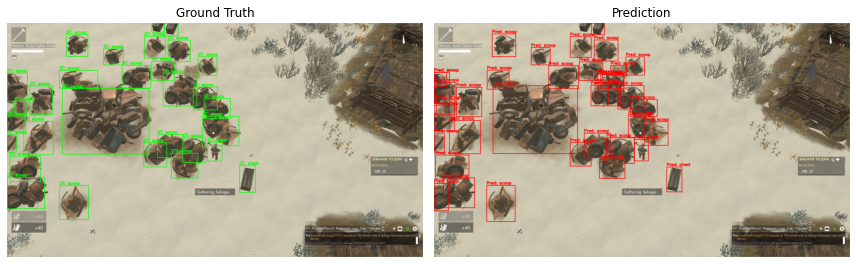


image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/images/val/screenshot(104).png: 384x640 1 center, 4 chests, 35 scoops, 36.8ms
Speed: 4.7ms preprocess, 36.8ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)


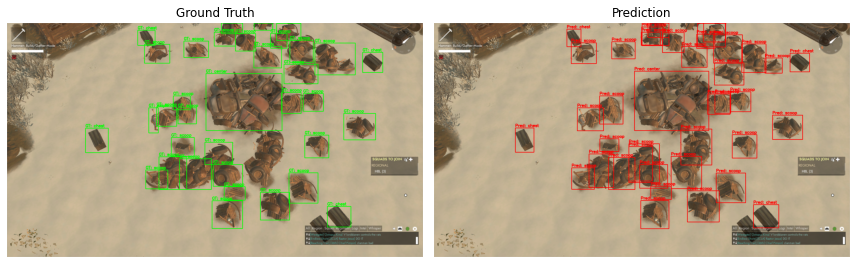


image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/images/val/screenshot(105).png: 384x640 1 center, 2 chests, 28 scoops, 37.4ms
Speed: 5.4ms preprocess, 37.4ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)


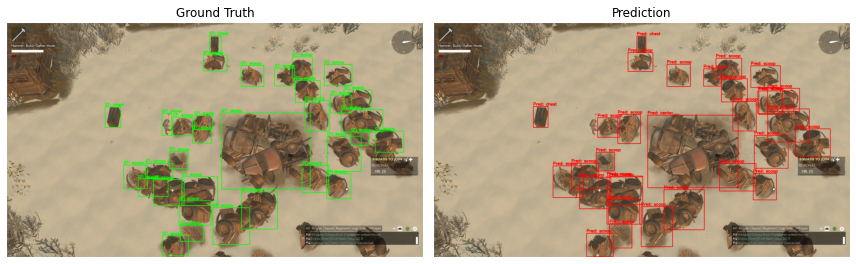


image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/images/val/screenshot(106).png: 384x640 1 center, 2 chests, 1 player, 30 scoops, 37.1ms
Speed: 5.7ms preprocess, 37.1ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)


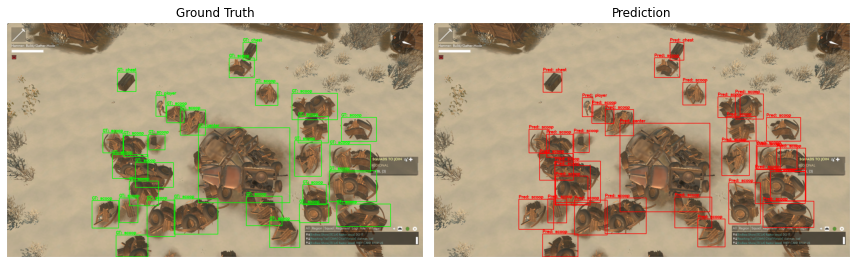


image 1/1 /home/panzer/git/cv_course_2025/seminars/seminar_11/datasets/images/val/screenshot(11).png: 384x640 1 center, 2 chests, 2 players, 5 scoops, 37.0ms
Speed: 4.3ms preprocess, 37.0ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)


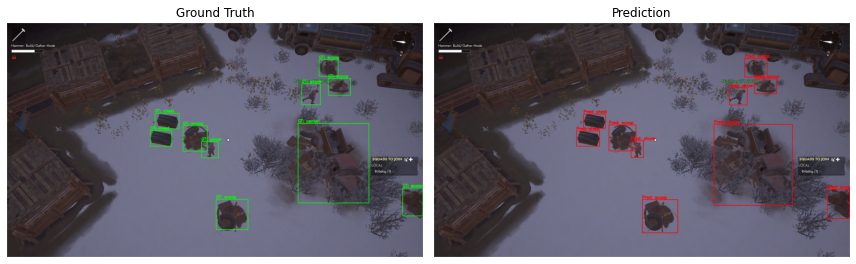

In [52]:
import cv2
import os
import matplotlib.pyplot as plt

# Paths
val_img_dir = "./datasets/images/val"
val_lbl_dir = "./datasets/labels/val"
class_file = os.path.join(YOLO_DIR, 'classes.txt') if 'YOLO_DIR' in locals() else './datasets/classes.txt'
if os.path.exists(class_file):
    with open(class_file, 'r') as f:
        class_names = [line.strip() for line in f.readlines()]
else:
    class_names = ["class_"+str(i) for i in range(10)]

# Helper to read YOLO label
def read_yolo_label(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, x, y, w, h = map(float, parts)
            boxes.append((int(cls), x, y, w, h))
    return boxes

# Helper to draw boxes
def draw_boxes(img, boxes, color=(0,255,0), label_prefix="", class_names=None):
    h, w = img.shape[:2]
    for box in boxes:
        cls, x, y, bw, bh = box
        # Convert from YOLO to pixel coords
        cx, cy = int(x * w), int(y * h)
        bw, bh = int(bw * w), int(bh * h)
        x1, y1 = int(cx - bw/2), int(cy - bh/2)
        x2, y2 = int(cx + bw/2), int(cy + bh/2)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{label_prefix}{class_names[cls] if class_names and cls < len(class_names) else str(cls)}"
        cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

# Visualize a few images
num_to_show = 5
val_imgs = sorted([f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))])[:num_to_show]

for img_name in val_imgs:
    img_path = os.path.join(val_img_dir, img_name)
    lbl_path = os.path.join(val_lbl_dir, os.path.splitext(img_name)[0] + ".txt")
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_boxes = read_yolo_label(lbl_path)
    img_gt = img_rgb.copy()
    img_gt = draw_boxes(img_gt, gt_boxes, color=(0,255,0), label_prefix="GT: ", class_names=class_names)

    # Model prediction
    results = model(img_path)
    pred_boxes = []
    for r in results:
        if hasattr(r, 'boxes') and r.boxes is not None:
            for b in r.boxes:
                # b.xywhn: normalized xywh, b.cls: class index
                if hasattr(b, 'xywhn') and hasattr(b, 'cls'):
                    xywh = b.xywhn.cpu().numpy().flatten()
                    cls = int(b.cls.cpu().numpy().flatten()[0])
                    pred_boxes.append((cls, *xywh))
    img_pred = img_rgb.copy()
    img_pred = draw_boxes(img_pred, pred_boxes, color=(255,0,0), label_prefix="Pred: ", class_names=class_names)

    # Show side by side
    fig, axs = plt.subplots(1,2, figsize=(12,6))
    axs[0].imshow(img_gt)
    axs[0].set_title("Ground Truth")
    axs[0].axis('off')
    axs[1].imshow(img_pred)
    axs[1].set_title("Prediction")
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()



Готово!
